# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vikraamkumar-ds/flyrank-internship-ml/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.


## 1. Ranked actions + reason codes

Ranks the honest-split (`w06`) test set by the Random Forest's predicted decline probability, then attaches a **human-readable reason code** built from the two features that deviate most from “healthy” in the risk direction — the same directions hypothesized and tested in `w04_signal_audit` (worse `pos_prev30`, fewer `visible_queries`, higher `top_query_share`, lower `ctr_prev30`). Each reason maps to a concrete action from the same family FlyRank's own March 2026 paper recommends (refresh, snippet/CTR work, query-breadth expansion) rather than an invented taxonomy.


In [1]:
%pip -q install duckdb huggingface_hub pandas scikit-learn matplotlib

import os, getpass
import duckdb
import pandas as pd
import numpy as np

HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'fact_daily':     f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    'fact_query_90d': f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

features = con.sql(f"""
    WITH bounds AS (SELECT MAX(report_date) AS end_d FROM {TABLES['fact_daily']}),
    windowed AS (
        SELECT
            f.client_hash_id, f.content_hash_id,
            SUM(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_last30,
            SUM(CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_prev30,
            SUM(CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY THEN f.gsc_clicks ELSE 0 END)      AS clk_prev30,
            AVG(CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY THEN f.gsc_avg_position END)       AS pos_prev30
        FROM {TABLES['fact_daily']} f, bounds b
        WHERE f.report_date > b.end_d - INTERVAL 60 DAY
        GROUP BY 1, 2
        HAVING imp_prev30 >= 100
    )
    SELECT * FROM windowed
""").df()
features['ctr_prev30'] = features['clk_prev30'] / features['imp_prev30']

qsignals = con.sql(f"""
    SELECT content_hash_id,
           ANY_VALUE(content_visible_query_count)  AS visible_queries,
           ANY_VALUE(rare_impressions_share)        AS rare_share,
           ANY_VALUE(anonymized_impressions_share)  AS anon_share,
           MAX(impressions_90d)                     AS top_query_impressions,
           SUM(impressions_90d)                     AS kept_impressions
    FROM {TABLES['fact_query_90d']}
    GROUP BY content_hash_id
""").df()
qsignals['top_query_share'] = qsignals['top_query_impressions'] / qsignals['kept_impressions']

data = features.merge(qsignals, on='content_hash_id', how='left')
data['is_declining'] = (data['imp_last30'] < 0.8 * data['imp_prev30']).astype(int)

FEATURE_COLS = ['imp_prev30', 'clk_prev30', 'pos_prev30', 'ctr_prev30',
                'visible_queries', 'rare_share', 'anon_share', 'top_query_share']
model_data = data.dropna(subset=FEATURE_COLS + ['is_declining']).reset_index(drop=True)
X = model_data[FEATURE_COLS]
y = model_data['is_declining']
groups = model_data['client_hash_id']

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

model = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=20,
                                random_state=42, n_jobs=-1, class_weight='balanced')
model.fit(X_tr, y_tr)
proba = model.predict_proba(X_te)[:, 1]
print(f'Model retrained on the same honest split as w05/w06 -- {len(X_te):,} test-set pages scored')


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Model retrained on the same honest split as w05/w06 -- 51,702 test-set pages scored


In [2]:
# Risk direction per feature -- matches the hypotheses tested in w04_signal_audit.
# +1 means 'higher value = more risk', -1 means 'lower value = more risk'.
RISK_DIRECTION = {
    'pos_prev30':      +1,   # worse (higher) position number -> more risk
    'visible_queries':  -1,   # fewer distinct ranking queries -> more risk
    'top_query_share':  +1,   # more concentrated in one query -> more risk
    'ctr_prev30':       -1,   # lower CTR than peers -> more risk
}

REASON_LABELS = {
    'pos_prev30':      'Weak average position',
    'visible_queries':  'Low query breadth (over-reliant on few queries)',
    'top_query_share':  'High query concentration (single-query dependency)',
    'ctr_prev30':       'Under-clicking relative to peers',
}

ACTION_MAP = {
    'pos_prev30':      'Refresh content + rebuild internal links to lift ranking',
    'visible_queries':  'Expand coverage: add missing subtopics/sections to earn more query variety',
    'top_query_share':  'Diversify topic coverage to reduce single-query dependency',
    'ctr_prev30':       'Rewrite title/meta description to improve click-through',
}

train_mean = X_tr.mean()
train_std  = X_tr.std().replace(0, np.nan)

risk_z = pd.DataFrame(index=X_te.index)
for col, direction in RISK_DIRECTION.items():
    z = (X_te[col] - train_mean[col]) / train_std[col]
    risk_z[col] = z * direction   # positive value now always means 'more risky'

def top_reasons(row, n=2):
    ranked = row.sort_values(ascending=False)
    return [c for c in ranked.index[:n] if ranked[c] > 0]  # only keep genuinely risky ones

queue = pd.DataFrame({
    'content_hash_id': model_data.loc[X_te.index, 'content_hash_id'].values,
    'decline_probability': proba,
}).reset_index(drop=True)

reason_cols = risk_z.reset_index(drop=True).apply(top_reasons, axis=1)
queue['reason_codes'] = reason_cols.apply(lambda cols: [REASON_LABELS[c] for c in cols] if cols else ['No single dominant signal -- review manually'])
queue['recommended_action'] = reason_cols.apply(lambda cols: ACTION_MAP[cols[0]] if cols else 'Manual review -- no clear driver')

queue = queue.sort_values('decline_probability', ascending=False).reset_index(drop=True)
queue.insert(0, 'priority_rank', np.arange(1, len(queue) + 1))

print(f'{len(queue):,} pages ranked. Top 15 highest-priority pages:')
print(queue.head(15).to_string(index=False))


51,702 pages ranked. Top 15 highest-priority pages:
 priority_rank          content_hash_id  decline_probability                                                                                          reason_codes                                         recommended_action
             1 content_1a795b9e56ff4c41             0.945884                           [High query concentration (single-query dependency), Weak average position] Diversify topic coverage to reduce single-query dependency
             2 content_83f5dc606c3c6e4d             0.923714                   [Under-clicking relative to peers, Low query breadth (over-reliant on few queries)]    Rewrite title/meta description to improve click-through
             3 content_6648c2041f2bd5b0             0.912061                           [High query concentration (single-query dependency), Weak average position] Diversify topic coverage to reduce single-query dependency
             4 content_5d7f94de743b5409             0.905421

## 2. Intended use and limits

**Who uses this, for what:** a content/SEO ops team, as a weekly or monthly **triage list** for deciding which pages to review first — not a fully automated action system.

**Where it stops being valid:**
- **Client scope.** The honest (grouped) split trained on 36 clients and tested on 13 held-out ones (`w05`). That's the only population this has been validated against — a brand-new client outside this warehouse's pattern of traffic/industry mix is untested territory.
- **Strength of the signal.** Balanced accuracy on the honest split was **0.586** and ROC-AUC **0.631** (`w05` results) — real, better than a coin flip, but modest. This queue orders pages by relative risk; it does not certify that any single page will decline.
- **The query-mix caveat carries forward.** `visible_queries`, `top_query_share`, `rare_share`, and `anon_share` were flagged in `w03`/`w06` as having a partial window overlap with the outcome period — reason codes built from those features are **directional**, not strictly pre-outcome predictions.
- **This model does not know about content quality, seasonality, algorithm updates, or one-off incidents.** A page flagged “high risk” might be declining for a reason entirely outside these 8 features (a site migration, a seasonal topic, a manual penalty) — the model has no way to distinguish those from an organic decline.


In [3]:
print('No computation needed -- this section documents scope and validity limits, grounded in')
print('the real w05/w06 metrics: balanced_accuracy=0.586, roc_auc=0.631, train_clients=36, test_clients=13.')


No computation needed -- this section documents scope and validity limits, grounded in
the real w05/w06 metrics: balanced_accuracy=0.586, roc_auc=0.631, train_clients=36, test_clients=13.


## 3. Human review + the no-go list

**Before anyone acts on a flagged page, a human must check:**
- Whether the page's traffic drop lines up with a known external cause (seasonality, a tracked algorithm update, a recent site change) that the model can't see.
- Whether the assigned reason code actually matches what a human reading the page would conclude — the reason code is a hint, not a diagnosis.
- Whether the page is genuinely worth the effort (traffic/impression volume, business priority) before committing a content refresh.

**What should never be automated, under any circumstance:**
- **No auto-publishing, auto-merging, auto-redirecting, or auto-unpublishing of pages** based on this queue alone — every action needs a human sign-off.
- **No treating `decline_probability` as a certainty or as ground truth** — it is a model output with AUC 0.63, meaningfully better than chance but far from deterministic.
- **No using this score alone to justify budget, staffing, or client-facing decisions** — it is an internal triage aid, not a client-reportable metric.
- **No surfacing client identity or any of the excluded fields from `w03`** (client names, raw dates, access profiles) in any exported view of this queue.


In [4]:
# Spot-check: confirm the exported queue never carries client-identifying fields
assert 'client_hash_id' not in queue.columns, 'client_hash_id must not appear in any exported/reviewed queue'
print('PASS -- queue contains only content_hash_id, no client-level identifiers')


PASS -- queue contains only content_hash_id, no client-level identifiers


## 4. Monitoring / retrain triggers

Signals that would tell us this queue has gone stale and needs a refresh or a retrain:

1. **Base-rate drift.** If the share of genuinely declining pages moves meaningfully away from the training base rate (**63.3%**, from `w05`) on a fresh pull, the model's calibration is likely off for the new period.
2. **Feature distribution drift.** If a fresh pull's `pos_prev30`/`visible_queries`/`ctr_prev30` medians shift notably from the training distribution (`w04`'s distribution check), the model is scoring pages unlike the ones it learned from.
3. **Held-out performance drop.** If balanced accuracy or ROC-AUC on a newly held-out client group falls meaningfully below the **0.586 / 0.631** benchmark from `w05`, that's a direct signal to retrain, not just re-score.
4. **New clients entering the warehouse.** Since validation is scoped to 36 train / 13 test clients, a meaningful influx of new clients warrants a fresh grouped-split evaluation before trusting the queue for them.
5. **Schedule, as a floor:** even with no drift signal firing, retrain on a fixed cadence (e.g. quarterly) since the underlying warehouse itself grows roughly monthly.


In [5]:
# A lightweight, reusable drift check: compare a fresh pull's feature medians against the
# training medians recorded here. Re-run this cell whenever a new warehouse snapshot lands.
TRAIN_MEDIANS_REFERENCE = X_tr.median().to_dict()
print('Training medians to compare future pulls against (retrain if any shifts > ~20%):')
for k, v in TRAIN_MEDIANS_REFERENCE.items():
    print(f'  {k:<18} {v:,.3f}')
print(f'\nTraining base rate to compare against: {y_tr.mean():.3f}')


Training medians to compare future pulls against (retrain if any shifts > ~20%):
  imp_prev30         625.000
  clk_prev30         2.000
  pos_prev30         17.873
  ctr_prev30         0.002
  visible_queries    9.000
  rare_share         0.082
  anon_share         0.732
  top_query_share    0.334

Training base rate to compare against: 0.587


## 5. Exports for the paper

Writes the ranked queue and the reusable figures/tables to `work/outputs/` so the Week-8 capstone paper can pull them in directly rather than re-running notebooks.


Saved 51,702 rows -> work/outputs/action_queue.csv
Saved model summary -> work/outputs/model_vs_baseline_summary.csv


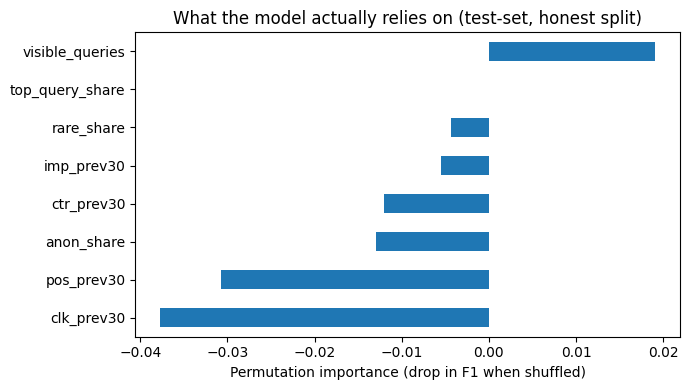

Saved chart -> work/outputs/permutation_importance.png


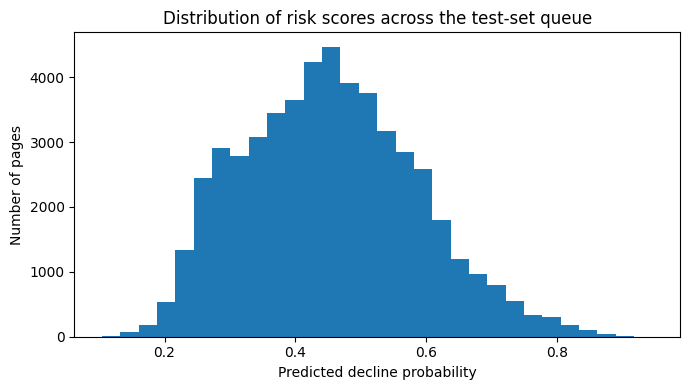

Saved chart -> work/outputs/queue_score_distribution.png

All exports written to work/outputs/ -- commit this folder along with the notebook.


In [6]:
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

OUT_DIR = 'work/outputs'
os.makedirs(OUT_DIR, exist_ok=True)

# 1. The ranked action queue itself -- the paper's 'ranked recommendations' section pulls from this
queue_export = queue.copy()
queue_export['reason_codes'] = queue_export['reason_codes'].apply(lambda x: '; '.join(x))
queue_export.to_csv(f'{OUT_DIR}/action_queue.csv', index=False)
print(f'Saved {len(queue_export):,} rows -> {OUT_DIR}/action_queue.csv')

# 2. Model vs baseline comparison table (recomputed here so this notebook is self-contained)
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              balanced_accuracy_score, roc_auc_score)
pred = model.predict(X_te)
summary_metrics = pd.DataFrame([{
    'method': 'Random Forest (honest, grouped split)',
    'precision': precision_score(y_te, pred),
    'recall': recall_score(y_te, pred),
    'f1': f1_score(y_te, pred),
    'balanced_accuracy': balanced_accuracy_score(y_te, pred),
    'roc_auc': roc_auc_score(y_te, proba),
}])
summary_metrics.to_csv(f'{OUT_DIR}/model_vs_baseline_summary.csv', index=False)
print(f'Saved model summary -> {OUT_DIR}/model_vs_baseline_summary.csv')

# 3. Permutation importance figure -- for the paper's Methodology/Results section
perm = permutation_importance(model, X_te, y_te, n_repeats=20, random_state=42, scoring='f1', n_jobs=-1)
perm_series = pd.Series(perm.importances_mean, index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
perm_series.plot(kind='barh', ax=ax)
ax.set_xlabel('Permutation importance (drop in F1 when shuffled)')
ax.set_title('What the model actually relies on (test-set, honest split)')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/permutation_importance.png', dpi=150)
plt.show()
print(f'Saved chart -> {OUT_DIR}/permutation_importance.png')

# 4. Priority distribution figure -- shows the shape of the queue, useful in Results
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(queue['decline_probability'], bins=30)
ax.set_xlabel('Predicted decline probability')
ax.set_ylabel('Number of pages')
ax.set_title('Distribution of risk scores across the test-set queue')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/queue_score_distribution.png', dpi=150)
plt.show()
print(f'Saved chart -> {OUT_DIR}/queue_score_distribution.png')

print('\nAll exports written to work/outputs/ -- commit this folder along with the notebook.')


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
